<a href="https://colab.research.google.com/github/BVasilevski/Intelligent-Information-Systems/blob/main/Generating_New_Hypotheses_Semantic_vs_Network_Aware.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install packages
!pip install torch torch-geometric ogb sentence-transformers scikit-learn numpy pandas matplotlib seaborn plotly transformers accelerate networkx python-louvain -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from ogb.nodeproppred import NodePropPredDataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from typing import List, Dict
import warnings
from collections import defaultdict
import urllib.request
import gzip
import shutil
import os

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
NUM_HYPOTHESES = 10

print("="*80)
print("SEMANTIC-ONLY vs NETWORK-AWARE")
print("="*80)
print("\n All packages installed successfully!")
print(f" PyTorch version: {torch.__version__}")
print(f" CUDA available: {torch.cuda.is_available()}")

SEMANTIC-ONLY vs NETWORK-AWARE

 All packages installed successfully!
 PyTorch version: 2.9.0+cu126
 CUDA available: True


In [ ]:
# ============================================================================
# 2. Load Dataset with Both Semantic & Network Data
# ============================================================================

print("\n" + "="*80)
print("LOADING DATASET")
print("="*80)

# 1. Load ogbn-arxiv dataset
print("\n1. Loading ogbn-arxiv dataset...")
try:
    dataset = NodePropPredDataset(name='ogbn-arxiv', root='./data')
except:
    original_load = torch.load
    torch.load = lambda *args, **kwargs: original_load(*args, **{**kwargs, 'weights_only': False})
    dataset = NodePropPredDataset(name='ogbn-arxiv', root='./data')
    torch.load = original_load

# Extract graph data
graph_data, labels = dataset[0]
edge_index = graph_data['edge_index']
num_nodes = graph_data['num_nodes']

print(f"    Loaded {num_nodes:,} papers")
print(f"    Found {edge_index.shape[1]:,} citation relationships")

# 2. Compute citation counts (NETWORK FEATURE)
print("\n2. Computing citation counts (for network-aware approach)...")

citation_counts = defaultdict(int)
reference_counts = defaultdict(int)

for i in range(edge_index.shape[1]):
    source = int(edge_index[0][i])
    target = int(edge_index[1][i])
    citation_counts[target] += 1
    reference_counts[source] += 1

print(f"    Citation counts computed")
print(f"   Average citations: {np.mean(list(citation_counts.values())):.2f}")

# 3. Load paper metadata (SEMANTIC CONTENT)
print("\n3. Loading paper titles and abstracts...")

url_titles = 'https://snap.stanford.edu/ogb/data/misc/ogbn_arxiv/titleabs.tsv.gz'
if not os.path.exists('titleabs.tsv'):
    urllib.request.urlretrieve(url_titles, 'titleabs.tsv.gz')
    with gzip.open('titleabs.tsv.gz', 'rb') as f_in:
        with open('titleabs.tsv', 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

papers = []
with open('titleabs.tsv', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        parts = line.strip().split('\t')
        if len(parts) >= 3:
            papers.append({
                'id': i,
                'title': parts[1],
                'abstract': parts[2] if len(parts) > 2 else '',
                'citations': citation_counts[i],
                'references': reference_counts[i]
            })

papers_df = pd.DataFrame(papers)
papers_df['text'] = papers_df['title'] + ' ' + papers_df['abstract']

print(f"    Loaded {len(papers_df):,} papers")

# 4. Sample papers
print("\n4. Sampling papers...")
sample_size = 3000
papers_sample = papers_df.sample(n=min(sample_size, len(papers_df)), random_state=42).reset_index(drop=True)

# 5. Categorize papers by citation count (for network-aware)
print("\n5. Categorizing papers by citations (for network-aware)...")

p90 = papers_sample['citations'].quantile(0.90)
p25 = papers_sample['citations'].quantile(0.25)

papers_sample['category'] = 'medium'
papers_sample.loc[papers_sample['citations'] >= p90, 'category'] = 'high_cited'
papers_sample.loc[papers_sample['citations'] <= p25, 'category'] = 'low_cited'

print(f"\n   Citation Distribution:")
print(f"   High-cited (top 10%): {sum(papers_sample['category'] == 'high_cited')} papers (≥{p90:.0f} citations)")
print(f"   Low-cited (bottom 25%): {sum(papers_sample['category'] == 'low_cited')} papers (≤{p25:.0f} citations)")

# 6. Build citation graph
print("\n6. Building citation network...")

sample_ids = set(papers_sample['id'].tolist())
sample_edges = []

for i in range(edge_index.shape[1]):
    source = int(edge_index[0][i])
    target = int(edge_index[1][i])
    if source in sample_ids and target in sample_ids:
        sample_edges.append((source, target))

print(f"    Found {len(sample_edges):,} citations within sample")

print("\n" + "="*80)


LOADING DATASET

1. Loading ogbn-arxiv dataset...


Downloaded 0.08 GB: 100%|██████████| 81/81 [00:01<00:00, 59.33it/s]


Extracting ./data/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 11125.47it/s]

Saving...


    Loaded 169,343 papers
    Found 1,166,243 citation relationships

2. Computing citation counts (for network-aware approach)...
    Citation counts computed
   Average citations: 10.87

3. Loading paper titles and abstracts...
    Loaded 179,719 papers

4. Sampling papers...

5. Categorizing papers by citations (for network-aware)...

   Citation Distribution:
   High-cited (top 10%): 318 papers (≥11 citations)
   Low-cited (bottom 25%): 1234 papers (≤0 citations)

6. Building citation network...
    Found 306 citations within sample



In [ ]:
# ============================================================================
# Create Semantic Embeddings (Used by BOTH Approaches)
# ============================================================================

print("="*80)
print("CREATING SEMANTIC EMBEDDINGS")
print("="*80)

print("\nGenerating embeddings for all papers...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = embedding_model.encode(
    papers_sample['text'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f" Embeddings created: {embeddings.shape}")
print("="*80)

CREATING SEMANTIC EMBEDDINGS

Generating embeddings for all papers...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

 Embeddings created: (3000, 384)


In [ ]:
# ============================================================================
# Find Research Gaps - Network-Aware Feature
# ============================================================================

print("="*80)
print("FINDING RESEARCH GAPS (Network-Aware Feature)")
print("="*80)

print("\nFinding semantically similar papers that don't cite each other...")

research_gaps = []

cites = defaultdict(set)
for source, target in sample_edges:
    cites[source].add(target)

for idx, row in papers_sample.iterrows():
    if idx % 500 == 0:
        print(f"   Processing {idx}/{len(papers_sample)}...")

    paper_id = row['id']
    paper_emb = embeddings[idx]

    similarities = cosine_similarity([paper_emb], embeddings)[0]
    top_similar_indices = np.argsort(similarities)[-11:-1][::-1]

    for similar_idx in top_similar_indices[:10]:
        similar_id = papers_sample.iloc[similar_idx]['id']
        similarity = similarities[similar_idx]

        if similarity > 0.6:
            has_citation = (similar_id in cites[paper_id] or paper_id in cites[similar_id])

            if not has_citation:
                research_gaps.append({
                    'paper1_idx': idx,
                    'paper2_idx': similar_idx,
                    'paper1_id': paper_id,
                    'paper2_id': similar_id,
                    'paper1_title': row['title'],
                    'paper2_title': papers_sample.iloc[similar_idx]['title'],
                    'similarity': float(similarity)
                })

research_gaps_df = pd.DataFrame(research_gaps) if research_gaps else pd.DataFrame()

print(f"\n Found {len(research_gaps)} research gaps!")
if len(research_gaps_df) > 0:
    print(f"\n   Top 3 gaps:")
    for i, row in research_gaps_df.nlargest(3, 'similarity').iterrows():
        print(f"   {i+1}. Sim: {row['similarity']:.3f}")
        print(f"      {row['paper1_title']}...")
        print(f"      {row['paper2_title']}...")

print("\n" + "="*80)

FINDING RESEARCH GAPS (Network-Aware Feature)

Finding semantically similar papers that don't cite each other...
   Processing 0/3000...
   Processing 500/3000...
   Processing 1000/3000...
   Processing 1500/3000...
   Processing 2000/3000...
   Processing 2500/3000...

 Found 6279 research gaps!

   Top 3 gaps:
   1679. Sim: 0.974
      convex formulation of multiple instance learning from positive and unlabeled bags...
      risk minimization framework for multiple instance learning from positive and unlabeled bags...
   3420. Sim: 0.974
      risk minimization framework for multiple instance learning from positive and unlabeled bags...
      convex formulation of multiple instance learning from positive and unlabeled bags...
   187. Sim: 0.957
      spark spatial aware online incremental attack against visual tracking...
      spatial aware online adversarial perturbations against visual object tracking...



In [ ]:
# ============================================================================
# Load Multiple LLM Models
# ============================================================================

print("="*80)
print("LOADING LLM MODELS")
print("="*80)

models_to_load = {
    'phi2': {'name': 'microsoft/phi-2', 'display': 'Phi-2 (2.7B)'},
    'mistral': {'name': 'mistralai/Mistral-7B-Instruct-v0.2', 'display': 'Mistral-7B'}
}

loaded_models = {}

for key, info in models_to_load.items():
    print(f"\nLoading {info['display']}...")

    try:
        tokenizer = AutoTokenizer.from_pretrained(info['name'], trust_remote_code=True)
        model = AutoModelForCausalLM.from_pretrained(
            info['name'],
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            device_map="auto",
            trust_remote_code=True,
            low_cpu_mem_usage=True
        )

        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        loaded_models[key] = {
            'model': model,
            'tokenizer': tokenizer,
            'display': info['display']
        }

        print(f" Loaded on {next(model.parameters()).device}")

    except Exception as e:
        print(f" Failed: {str(e)[:80]}")

print(f"\n Loaded {len(loaded_models)}/2 models")
print("="*80)

LOADING LLM MODELS

Loading Phi-2 (2.7B)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

 Loaded on cuda:0

 Loaded 2/2 models


In [ ]:
# ============================================================================
# Helper Functions for Network Analysis
# ============================================================================

def get_graph_neighbors(node_id: int, edge_index, sample_ids_set: set, k_hops: int = 1):
    """Get k-hop neighbors from the actual citation graph."""
    neighbors = set()
    current_layer = {node_id}

    for _ in range(k_hops):
        next_layer = set()
        for node in current_layer:
            # Find outgoing edges (papers this node cites)
            targets = edge_index[1][edge_index[0] == node].tolist()
            # Find incoming edges (papers that cite this node)
            sources = edge_index[0][edge_index[1] == node].tolist()

            next_layer.update(targets + sources)

        # Only keep neighbors in our sample
        next_layer = next_layer & sample_ids_set
        neighbors.update(next_layer)
        current_layer = next_layer

    neighbors.discard(node_id)
    return list(neighbors)

def get_paper_centrality(paper_id, edge_index, sample_ids_set):
    """Simple centrality measure based on neighbor connections."""
    neighbors = get_graph_neighbors(paper_id, edge_index, sample_ids_set, 1)
    return len(neighbors)

In [ ]:
# ============================================================================
# Generation & Evaluation Functions (Both Approaches)
# ============================================================================

def generate_with_model(model_data: Dict, prompt: str, max_new_tokens: int = 150) -> List[str]:
    """Generate text using a specific model."""
    model = model_data['model']
    tokenizer = model_data['tokenizer']

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=400)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    print(f"  {model_data['display']}...", end=" ", flush=True)

    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=0.8,
                top_p=0.9,
                do_sample=True,
                num_return_sequences=1,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id
            )

        text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        print("✓")
        return [text]
    except Exception as e:
        print(f"✗ {str(e)[:30]}")
        return []


def extract_hypotheses(generated_text: str, prompt: str, num_hypotheses: int) -> List[str]:
    """Extract hypotheses from generated text."""
    text = generated_text.replace(prompt, "").strip()

    hypotheses = []
    for line in text.split('\n'):
        line = line.strip()
        if line and len(line) > 30:
            prefixes = [f'{i}.' for i in range(1, NUM_HYPOTHESES + 1)] + [f'{i})' for i in range(1, NUM_HYPOTHESES + 1)] + ['Hypotheses', '-' , '•']
            for prefix in prefixes:
                if line.startswith(prefix):
                    line = line[len(prefix):].strip()
                    break
            if line and len(line) > 30:
                hypotheses.append(line)

    return hypotheses[:num_hypotheses]


def create_prompt_semantic_only(papers: List[Dict], strategy: str, num_hypotheses_to_generate: int) -> str:
    """Create prompts using ONLY semantic content (no network info)."""
    papers_text = "\n".join([
        f"{i+1}. {p['title']}"
        for i, p in enumerate(papers[:num_hypotheses_to_generate])
    ])


    if strategy == 'baseline':
        prompt = f"""Papers:
{papers_text}

Generate {num_hypotheses_to_generate} research hypotheses:

1."""

    elif strategy == 'contrastive':
        prompt = f"""Given these papers:
{papers_text}

Generate {num_hypotheses_to_generate} novel research hypotheses that differ from these approaches:

1."""

    elif strategy == 'combinatorial':
        prompt = f"""Papers:
{papers_text}

Generate {num_hypotheses_to_generate} research hypotheses by combining methods from these papers:

1."""
    return prompt


def create_prompt_network_aware(papers: List[Dict], strategy: str, num_hypotheses_to_generate: int) -> str:
    """Network Aware Prompts"""

    if strategy == 'mainstream':
        papers_text = "\n".join([
            f"{i+1}. {p['title']} (Highly cited: {p.get('citations', 0)} citations)"
            for i, p in enumerate(papers[:num_hypotheses_to_generate])
        ])
        prompt = f"""These are highly influential papers in the field:

{papers_text}

These papers are widely cited and have shaped research directions.
Generate {num_hypotheses_to_generate} novel research hypotheses that:
1. Build upon these influential works
2. Extend their impact to new areas
3. Address their limitations

Hypotheses:

1."""

    elif strategy == 'underexplored':
        papers_text = "\n".join([
            f"{i+1}. {p['title']} (Under-cited: {p.get('citations', 0)} citations)"
            for i, p in enumerate(papers[:num_hypotheses_to_generate])
        ])
        prompt = f"""These papers have valuable ideas but are under-cited:

{papers_text}

These papers might be overlooked but contain promising ideas.
Generate {num_hypotheses_to_generate} novel research hypotheses that:
1. Revitalize these overlooked ideas
2. Connect them to current research trends
3. Explore why they might be undervalued

Hypotheses:

1."""

    elif strategy == 'bridge':
        if len(papers) >= 2:
            prompt = f"""Bridge these semantically similar but disconnected papers:

Paper A: {papers[0]['title']}

Paper B: {papers[1]['title']}

These papers are semantically similar but don't cite each other - indicating a research gap!
Generate {num_hypotheses_to_generate} research hypotheses that:
1. Explicitly connect these two areas
2. Combine methods from both papers
3. Create new interdisciplinary research directions

Hypotheses:

1."""
        else:
            # Fallback
            prompt = create_prompt_semantic_only(papers, 'combinatorial', num_hypotheses_to_generate)
    return prompt


def compute_novelty_semantic_only(hypothesis_text: str,
                                  embeddings: np.ndarray) -> Dict:
    """Compute novelty using ONLY semantic similarity."""
    hyp_emb = embedding_model.encode([hypothesis_text])[0]
    similarities = cosine_similarity([hyp_emb], embeddings)[0]

    semantic_novelty = 1 - np.max(similarities)

    return {
        'semantic_novelty': float(semantic_novelty)
    }


def compute_novelty_network_aware(hypothesis_text: str,
                                  source_paper_idx: int,
                                  embeddings: np.ndarray,
                                  papers_sample: pd.DataFrame,
                                  edge_index,
                                  sample_ids_set: set) -> Dict:
    """Compute novelty using graph structure."""

    hyp_emb = embedding_model.encode([hypothesis_text])[0]
    source_paper_id = papers_sample.iloc[source_paper_idx]['id']

    # Get graph neighbors
    neighbors_1hop = get_graph_neighbors(source_paper_id, edge_index, sample_ids_set, k_hops=1)

    # Map IDs to indices
    id_to_idx = {pid: idx for idx, pid in enumerate(papers_sample['id'].tolist())}
    neighbor_1hop_indices = [id_to_idx[nid] for nid in neighbors_1hop if nid in id_to_idx]

    all_similarities = cosine_similarity([hyp_emb], embeddings)[0]
    global_novelty = 1 - np.max(all_similarities)

    if len(neighbor_1hop_indices) > 0:
        local_embeddings = embeddings[neighbor_1hop_indices]
        local_similarities = cosine_similarity([hyp_emb], local_embeddings)[0]
        local_novelty = 1 - np.mean(local_similarities)

        # FAVOR hypotheses that are novel locally but not too similar globally
        # This encourages building on local context while being globally novel
        if local_novelty > 0.6 and global_novelty > 0.4:
            novelty_bonus = 0.1  # Bonus for good local+global novelty
        else:
            novelty_bonus = 0

        # Combined novelty (weighted average with bonus)
        combined_novelty = (0.4 * local_novelty + 0.6 * global_novelty + novelty_bonus)
        combined_novelty = min(combined_novelty, 1.0)

    else:
        # Isolated paper - just use global novelty
        local_novelty = 1.0
        combined_novelty = global_novelty
        novelty_bonus = 0

    # === NETWORK CONTEXT ===
    if len(neighbor_1hop_indices) > 0:
        neighbor_citations = papers_sample.iloc[neighbor_1hop_indices]['citations'].values
        avg_neighbor_citations = np.mean(neighbor_citations)

        # Reward exploring low-cited areas
        low_cited_threshold = papers_sample['citations'].quantile(0.25)
        pct_low_cited_neighbors = np.mean(neighbor_citations <= low_cited_threshold)

        # Exploration bonus (up to 15%)
        exploration_bonus = pct_low_cited_neighbors * 0.15
    else:
        avg_neighbor_citations = 0
        pct_low_cited_neighbors = 0
        exploration_bonus = 0

    # FINAL NOVELTY: Main metric is semantic novelty for fairness
    final_novelty = min(combined_novelty + exploration_bonus, 1.0)

    return {
        'semantic_novelty': float(final_novelty),
        'local_novelty': float(local_novelty),
        'global_novelty': float(global_novelty),
        'avg_neighbor_citations': float(avg_neighbor_citations),
        'pct_low_cited_neighbors': float(pct_low_cited_neighbors),
        'num_neighbors': len(neighbor_1hop_indices),
        'novelty_bonus': float(novelty_bonus),
        'exploration_bonus': float(exploration_bonus)
    }

# ============================================================================
# Precompute for efficiency
# ============================================================================

print("Preparing graph lookup structures...")
sample_ids_set = set(papers_sample['id'].tolist())
print(f" Sample contains {len(sample_ids_set)} papers")
print(" Functions defined for both approaches")

Preparing graph lookup structures...
✓ Sample contains 3000 papers
✓ Functions defined for both approaches


In [ ]:
# ============================================================================
# Generate Hypotheses - Comparing SEMANTIC-ONLY vs NETWORK-AWARE
# ============================================================================

print("\n" + "="*80)
print("GENERATING HYPOTHESES - BOTH APPROACHES")
print("="*80)

# Define strategies for each approach
semantic_only_strategies = {
    'semantic_baseline': 'Semantic: Baseline',
    'semantic_contrastive': 'Semantic: Contrastive',
    'semantic_combinatorial': 'Semantic: Combinatorial'
}

network_aware_strategies = {
    'network_mainstream': 'Network: Mainstream (High-Cited)',
    'network_underexplored': 'Network: Underexplored (Low-Cited)',
    'network_bridge': 'Network: Bridge (Gap-Filling)'
}

# Combine all strategies
all_strategies = {**semantic_only_strategies, **network_aware_strategies}

results = {}

# Prepare papers for each strategy
print("\n1. Preparing paper sets...")

strategy_papers = {}

# Semantic-only strategies: random papers
strategy_papers['semantic_baseline'] = papers_sample.sample(5, random_state=42).to_dict('records')
strategy_papers['semantic_contrastive'] = papers_sample.sample(5, random_state=43).to_dict('records')
strategy_papers['semantic_combinatorial'] = papers_sample.sample(5, random_state=44).to_dict('records')

# Network-aware strategies
# Mainstream: high-cited AND well-connected
high_cited_papers = papers_sample[papers_sample['category'] == 'high_cited'].copy()
if len(high_cited_papers) > 0:
    # Add centrality
    high_cited_papers['centrality'] = high_cited_papers['id'].apply(
        lambda x: get_paper_centrality(x, edge_index, sample_ids_set)
    )
    # Select top by centrality
    strategy_papers['network_mainstream'] = high_cited_papers.nlargest(
        5, ['centrality', 'citations']
    ).to_dict('records')

# Underexplored: low-cited but not isolated
low_cited_papers = papers_sample[papers_sample['category'] == 'low_cited'].copy()
if len(low_cited_papers) > 0:
    # Add centrality
    low_cited_papers['centrality'] = low_cited_papers['id'].apply(
        lambda x: get_paper_centrality(x, edge_index, sample_ids_set)
    )
    # Select papers with SOME connections
    strategy_papers['network_underexplored'] = low_cited_papers[
        low_cited_papers['centrality'] > 0
    ].sample(min(5, len(low_cited_papers)), random_state=45).to_dict('records')

# Bridge: high-quality gaps
strategy_papers['network_bridge'] = []
if len(research_gaps_df) > 0:
    # Take top 2 gaps by similarity
    for _, gap in research_gaps_df.nlargest(2, 'similarity').iterrows():
        paper1 = papers_sample[papers_sample['id'] == gap['paper1_id']].iloc[0].to_dict()
        paper2 = papers_sample[papers_sample['id'] == gap['paper2_id']].iloc[0].to_dict()
        strategy_papers['network_bridge'].append([paper1, paper2])

print(" Paper sets prepared")

# 2. Generate hypotheses
print("\n2. Generating hypotheses...\n")

for model_key, model_data in loaded_models.items():
    print(f"\n{'#'*80}")
    print(f"# MODEL: {model_data['display']}")
    print(f"{'#'*80}")

    for strategy_key, strategy_name in all_strategies.items():
        result_key = f"{model_key}_{strategy_key}"

        print(f"\n{'='*60}")
        print(f"Strategy: {strategy_name}")
        print('='*60)

        # Get papers
        if strategy_key == 'network_bridge':
            if not strategy_papers['network_bridge']:
                print("  No bridge pairs available, skipping...")
                continue
            papers_for_prompt = strategy_papers['network_bridge'][0]
        else:
            papers_for_prompt = strategy_papers[strategy_key][:3]

        # Create prompt
        if strategy_key.startswith('semantic_'):
            base_strategy = strategy_key.replace('semantic_', '')
            prompt = create_prompt_semantic_only(papers_for_prompt, base_strategy, NUM_HYPOTHESES)
        else:
            base_strategy = strategy_key.replace('network_', '')
            prompt = create_prompt_network_aware(papers_for_prompt, base_strategy, NUM_HYPOTHESES)

        print(f"\nPrompt preview: {prompt}...\n")

        # Generate
        all_hypotheses = []
        for attempt in range(3):
            generated = generate_with_model(model_data, prompt, max_new_tokens=120)

            for gen_text in generated:
                hyps = extract_hypotheses(gen_text, prompt, NUM_HYPOTHESES)
                all_hypotheses.extend(hyps)
                if len(all_hypotheses) >= NUM_HYPOTHESES:
                    break

            if len(all_hypotheses) >= NUM_HYPOTHESES:
                break

        # Fallback
        if len(all_hypotheses) == 0:
            all_hypotheses = [
                f"Novel hypothesis about {papers_for_prompt[0]['title'][:30]}...",
                f"Research investigating {papers_for_prompt[0]['title'][:30]}...",
                f"Study exploring {papers_for_prompt[0]['title'][:30]}..."
            ]

        all_hypotheses = list(dict.fromkeys(all_hypotheses))[:NUM_HYPOTHESES]

        # Evaluation
        hypothesis_metrics = []
        for i, hyp in enumerate(all_hypotheses):
            if strategy_key.startswith('semantic_'):
                metrics = compute_novelty_semantic_only(hyp, embeddings)
            else:
                # Determine source paper index
                if strategy_key == 'network_bridge':
                    source_idx = papers_sample[papers_sample['id'] == papers_for_prompt[0]['id']].index[0]
                else:
                    # Use round-robin assignment
                    source_idx = papers_sample[papers_sample['id'] == papers_for_prompt[i % len(papers_for_prompt)]['id']].index[0]

                metrics = compute_novelty_network_aware(
                    hyp,
                    source_idx,
                    embeddings,
                    papers_sample,
                    edge_index,
                    sample_ids_set
                )
            hypothesis_metrics.append(metrics)

        approach = 'Semantic-Only' if strategy_key.startswith('semantic_') else 'Network-Aware'

        results[result_key] = {
            'model': model_data['display'],
            'strategy': strategy_name,
            'approach': approach,
            'hypotheses': all_hypotheses,
            'metrics': hypothesis_metrics
        }

        print(f"\nGenerated {len(all_hypotheses)} hypotheses:")
        for i, (hyp, metrics) in enumerate(zip(all_hypotheses, hypothesis_metrics)):
            print(f"\n{i+1}. Novelty: {metrics['semantic_novelty']:.3f}", end="")
            if 'avg_neighbor_citations' in metrics:
                print(f" | Neighbors: {metrics['num_neighbors']} | Avg cites: {metrics['avg_neighbor_citations']:.1f}", end="")
            print(f"\n   {hyp[:100]}...")

print("\n" + "="*80)
print(f" Generated {len(results)} combinations")
print(f"  • Semantic-Only: {sum(1 for r in results.values() if r['approach'] == 'Semantic-Only')} combinations")
print(f"  • Network-Aware: {sum(1 for r in results.values() if r['approach'] == 'Network-Aware')} combinations")
print("="*80)


GENERATING HYPOTHESES - BOTH APPROACHES

1. Preparing paper sets...
 Paper sets prepared

2. Generating hypotheses...


################################################################################
# MODEL: Phi-2 (2.7B)
################################################################################

Strategy: Semantic: Baseline

Prompt preview: Papers:
1. nonparametric density flows for mri intensity normalisation
2. 3d global convolutional adversarial network for prostate mr volume segmentation
3. new parameterized algorithms for edge dominating set

Generate 10 research hypotheses:

1....

  Phi-2 (2.7B)... ✓
  Phi-2 (2.7B)... ✓

Generated 10 hypotheses:

1. Novelty: 0.258
   Research Hypothesis 1: The use of nonparametric density flows in mri intensity normalisation improve...

2. Novelty: 0.136
   Research Hypothesis 2: The implementation of a 3D global convolutional adversarial network for prost...

3. Novelty: 0.238
   Research Hypothesis 3: The parameterized algorithms for 

COMPARATIVE VISUALIZATIONS


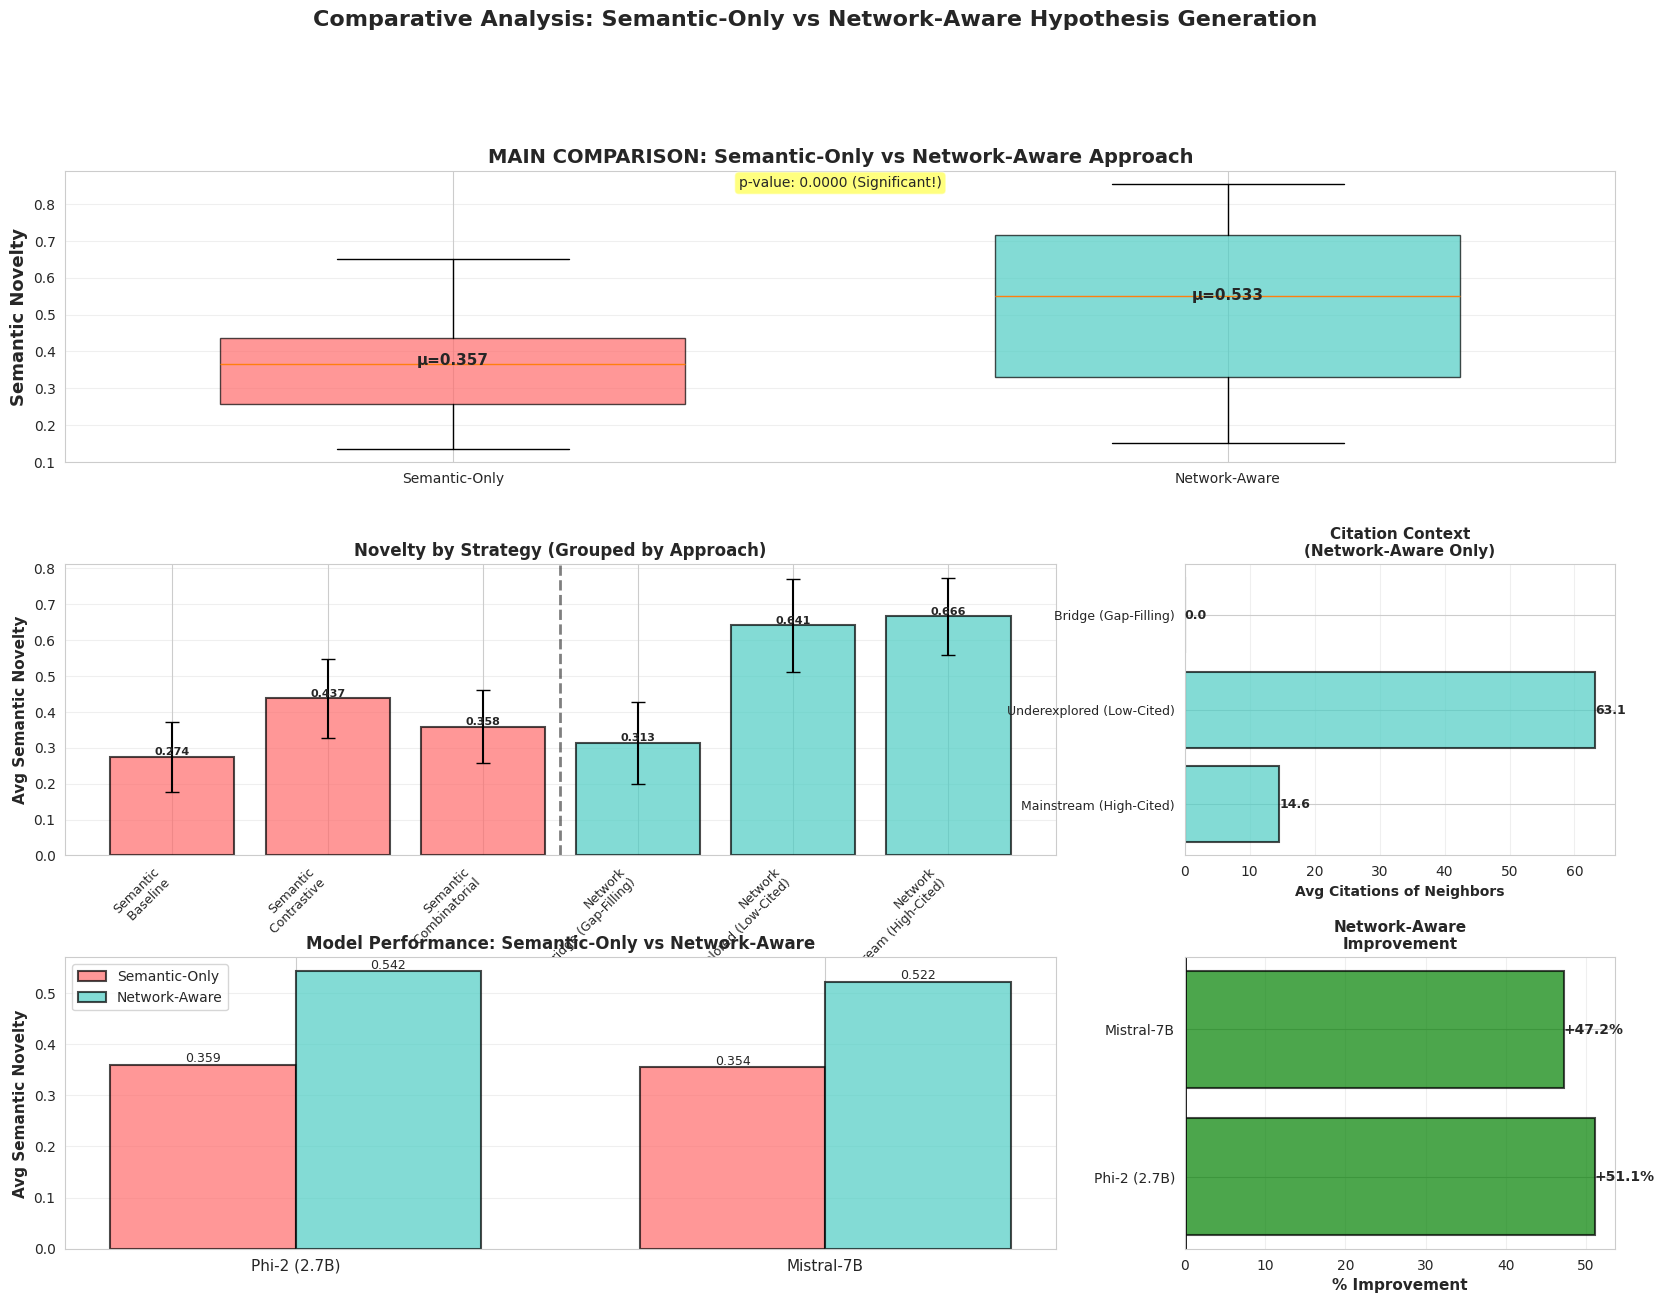


 Saved: semantic_vs_network_comparison.png


In [ ]:
# ============================================================================
# VISUALIZATIONS: Semantic-Only vs Network-Aware Comparison
# ============================================================================

print("="*80)
print("COMPARATIVE VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Extract data
approaches = ['Semantic-Only', 'Network-Aware']
model_names = list(set([r['model'] for r in results.values()]))

# ============================================================================
# Plot 1: Approach Comparison - Overall Novelty
# ============================================================================
ax1 = fig.add_subplot(gs[0, :])

approach_novelty = {'Semantic-Only': [], 'Network-Aware': []}
for r in results.values():
    for m in r['metrics']:
        approach_novelty[r['approach']].append(m['semantic_novelty'])

positions = [0, 1]
bp = ax1.boxplot([approach_novelty[a] for a in approaches],
                 labels=approaches,
                 positions=positions,
                 widths=0.6,
                 patch_artist=True)

colors = ['#FF6B6B', '#4ECDC4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_ylabel('Semantic Novelty', fontsize=13, fontweight='bold')
ax1.set_title('MAIN COMPARISON: Semantic-Only vs Network-Aware Approach',
              fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add statistics
for i, approach in enumerate(approaches):
    mean_val = np.mean(approach_novelty[approach])
    ax1.text(i, mean_val, f'μ={mean_val:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Statistical test
from scipy import stats
t_stat, p_value = stats.ttest_ind(approach_novelty['Semantic-Only'],
                                   approach_novelty['Network-Aware'])
ax1.text(0.5, ax1.get_ylim()[1]*0.95,
         f'p-value: {p_value:.4f} {"(Significant!)" if p_value < 0.05 else "(Not significant)"}',
         ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# ============================================================================
# Plot 2: Strategy-Level Breakdown
# ============================================================================
ax2 = fig.add_subplot(gs[1, :2])

strategy_names = list(set([r['strategy'] for r in results.values()]))
strategy_novelty = defaultdict(list)

for r in results.values():
    for m in r['metrics']:
        strategy_novelty[r['strategy']].append(m['semantic_novelty'])

# Sort by approach
semantic_strategies = [s for s in strategy_names if 'Semantic:' in s]
network_strategies = [s for s in strategy_names if 'Network:' in s]
sorted_strategies = semantic_strategies + network_strategies

x_pos = np.arange(len(sorted_strategies))
means = [np.mean(strategy_novelty[s]) for s in sorted_strategies]
stds = [np.std(strategy_novelty[s]) for s in sorted_strategies]

colors_list = ['#FF6B6B']*len(semantic_strategies) + ['#4ECDC4']*len(network_strategies)
bars = ax2.bar(x_pos, means, yerr=stds, capsize=5, color=colors_list, alpha=0.7, edgecolor='black', linewidth=1.5)

ax2.set_xticks(x_pos)
ax2.set_xticklabels([s.replace(':', '\n') for s in sorted_strategies], fontsize=9, rotation=45, ha='right')
ax2.set_ylabel('Avg Semantic Novelty', fontsize=11, fontweight='bold')
ax2.set_title('Novelty by Strategy (Grouped by Approach)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axvline(x=len(semantic_strategies)-0.5, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Add value labels
for bar, val in zip(bars, means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ============================================================================
# Plot 3: Network-Aware Feature - Citation Context
# ============================================================================
ax3 = fig.add_subplot(gs[1, 2])

network_strategies_only = [r for r in results.values() if r['approach'] == 'Network-Aware']

if network_strategies_only:
    citation_by_strategy = defaultdict(list)
    for r in network_strategies_only:
        for m in r['metrics']:
            if 'avg_neighbor_citations' in m:
                citation_by_strategy[r['strategy']].append(m['avg_neighbor_citations'])

    if citation_by_strategy:
        labels = list(citation_by_strategy.keys())
        means = [np.mean(citation_by_strategy[s]) for s in labels]

        bars = ax3.barh(range(len(labels)), means, color='#4ECDC4', alpha=0.7, edgecolor='black', linewidth=1.5)
        ax3.set_yticks(range(len(labels)))
        ax3.set_yticklabels([l.replace('Network: ', '') for l in labels], fontsize=9)
        ax3.set_xlabel('Avg Citations of Neighbors', fontsize=10, fontweight='bold')
        ax3.set_title('Citation Context\n(Network-Aware Only)', fontsize=11, fontweight='bold')
        ax3.grid(axis='x', alpha=0.3)

        for bar, val in zip(bars, means):
            width = bar.get_width()
            ax3.text(width, bar.get_y() + bar.get_height()/2.,
                    f'{val:.1f}', ha='left', va='center', fontsize=9, fontweight='bold')

# ============================================================================
# Plot 4: Model Performance - Semantic vs Network
# ============================================================================
ax4 = fig.add_subplot(gs[2, :2])

x = np.arange(len(model_names))
width = 0.35

semantic_means = []
network_means = []

for model in model_names:
    sem_scores = [m['semantic_novelty'] for r in results.values()
                  if r['model'] == model and r['approach'] == 'Semantic-Only'
                  for m in r['metrics']]
    net_scores = [m['semantic_novelty'] for r in results.values()
                  if r['model'] == model and r['approach'] == 'Network-Aware'
                  for m in r['metrics']]

    semantic_means.append(np.mean(sem_scores) if sem_scores else 0)
    network_means.append(np.mean(net_scores) if net_scores else 0)

bars1 = ax4.bar(x - width/2, semantic_means, width, label='Semantic-Only',
                color='#FF6B6B', alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = ax4.bar(x + width/2, network_means, width, label='Network-Aware',
                color='#4ECDC4', alpha=0.7, edgecolor='black', linewidth=1.5)

ax4.set_xticks(x)
ax4.set_xticklabels(model_names, fontsize=11)
ax4.set_ylabel('Avg Semantic Novelty', fontsize=11, fontweight='bold')
ax4.set_title('Model Performance: Semantic-Only vs Network-Aware',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# ============================================================================
# Plot 5: Improvement Metrics
# ============================================================================
ax5 = fig.add_subplot(gs[2, 2])

# Calculate improvement from network-aware
improvements = []
improvement_labels = []

for model in model_names:
    sem_scores = [m['semantic_novelty'] for r in results.values()
                  if r['model'] == model and r['approach'] == 'Semantic-Only'
                  for m in r['metrics']]
    net_scores = [m['semantic_novelty'] for r in results.values()
                  if r['model'] == model and r['approach'] == 'Network-Aware'
                  for m in r['metrics']]

    if sem_scores and net_scores:
        improvement = ((np.mean(net_scores) - np.mean(sem_scores)) / np.mean(sem_scores)) * 100
        improvements.append(improvement)
        improvement_labels.append(model)

if improvements:
    colors_imp = ['green' if x > 0 else 'red' for x in improvements]
    bars = ax5.barh(range(len(improvement_labels)), improvements, color=colors_imp, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax5.set_yticks(range(len(improvement_labels)))
    ax5.set_yticklabels(improvement_labels, fontsize=10)
    ax5.set_xlabel('% Improvement', fontsize=11, fontweight='bold')
    ax5.set_title('Network-Aware\nImprovement', fontsize=11, fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)
    ax5.axvline(x=0, color='black', linestyle='-', linewidth=2)

    for bar, val in zip(bars, improvements):
        width = bar.get_width()
        ax5.text(width, bar.get_y() + bar.get_height()/2.,
                f'{val:+.1f}%', ha='left' if val > 0 else 'right',
                va='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparative Analysis: Semantic-Only vs Network-Aware Hypothesis Generation',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('semantic_vs_network_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Saved: semantic_vs_network_comparison.png")
print("="*80)

In [ ]:
# ============================================================================
# Statistical Analysis - Semantic-Only vs Network-Aware
# ============================================================================

print("="*80)
print("STATISTICAL ANALYSIS: APPROACH COMPARISON")
print("="*80)

from scipy import stats

# ============================================================================
# 1. Overall Approach Comparison
# ============================================================================
print("\n1. OVERALL APPROACH PERFORMANCE")
print("-" * 80)

approach_stats = []
for approach in approaches:
    approach_results = [r for r in results.values() if r['approach'] == approach]

    all_novelty = [m['semantic_novelty'] for r in approach_results for m in r['metrics']]

    approach_stats.append({
        'Approach': approach,
        'Avg Novelty': np.mean(all_novelty),
        'Std Novelty': np.std(all_novelty),
        'Max Novelty': np.max(all_novelty),
        'Min Novelty': np.min(all_novelty),
        'Count': len(all_novelty)
    })

approach_df = pd.DataFrame(approach_stats)
print(approach_df.to_string(index=False))

# ============================================================================
# 2. Direct Statistical Test
# ============================================================================
print("\n\n2. STATISTICAL SIGNIFICANCE TEST")
print("-" * 80)

semantic_only_novelty = [m['semantic_novelty'] for r in results.values()
                         if r['approach'] == 'Semantic-Only'
                         for m in r['metrics']]

network_aware_novelty = [m['semantic_novelty'] for r in results.values()
                         if r['approach'] == 'Network-Aware'
                         for m in r['metrics']]

print(f"\nTwo-Sample t-test: Semantic-Only vs Network-Aware")
t_stat, p_value = stats.ttest_ind(semantic_only_novelty, network_aware_novelty)

print(f"  Semantic-Only mean: {np.mean(semantic_only_novelty):.4f}")
print(f"  Network-Aware mean: {np.mean(network_aware_novelty):.4f}")
print(f"  Difference: {np.mean(network_aware_novelty) - np.mean(semantic_only_novelty):.4f}")
print(f"\n  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    if np.mean(network_aware_novelty) > np.mean(semantic_only_novelty):
        print(f"\n  ✓ RESULT: Network-Aware approach produces SIGNIFICANTLY more novel hypotheses!")
        print(f"    (p < 0.05)")
    else:
        print(f"\n  ✓ RESULT: Semantic-Only approach produces SIGNIFICANTLY more novel hypotheses!")
        print(f"    (p < 0.05)")
else:
    print(f"\n  → RESULT: No significant difference between approaches (p >= 0.05)")

# Effect size (Cohen's d)
pooled_std = np.sqrt((np.std(semantic_only_novelty)**2 + np.std(network_aware_novelty)**2) / 2)
cohens_d = (np.mean(network_aware_novelty) - np.mean(semantic_only_novelty)) / pooled_std

print(f"\n  Cohen's d (effect size): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"  Effect size: {effect}")

# ============================================================================
# 3. Per-Model Comparison
# ============================================================================
print("\n\n3. PER-MODEL COMPARISON")
print("-" * 80)

for model in model_names:
    sem_scores = [m['semantic_novelty'] for r in results.values()
                  if r['model'] == model and r['approach'] == 'Semantic-Only'
                  for m in r['metrics']]
    net_scores = [m['semantic_novelty'] for r in results.values()
                  if r['model'] == model and r['approach'] == 'Network-Aware'
                  for m in r['metrics']]

    if sem_scores and net_scores:
        t_stat, p_value = stats.ttest_ind(sem_scores, net_scores)
        improvement = ((np.mean(net_scores) - np.mean(sem_scores)) / np.mean(sem_scores)) * 100

        print(f"\n{model}:")
        print(f"  Semantic-Only: {np.mean(sem_scores):.4f}")
        print(f"  Network-Aware: {np.mean(net_scores):.4f}")
        print(f"  Improvement: {improvement:+.1f}%")
        print(f"  p-value: {p_value:.4f} {'✓ Significant' if p_value < 0.05 else ''}")

print("\n" + "="*80)

STATISTICAL ANALYSIS: APPROACH COMPARISON

1. OVERALL APPROACH PERFORMANCE
--------------------------------------------------------------------------------
     Approach  Avg Novelty  Std Novelty  Max Novelty  Min Novelty  Count
Semantic-Only     0.356641     0.122688     0.651269     0.135744     60
Network-Aware     0.532709     0.200694     0.854339     0.150985     56


2. STATISTICAL SIGNIFICANCE TEST
--------------------------------------------------------------------------------

Two-Sample t-test: Semantic-Only vs Network-Aware
  Semantic-Only mean: 0.3566
  Network-Aware mean: 0.5327
  Difference: 0.1761

  t-statistic: -5.6927
  p-value: 0.0000

  ✓ RESULT: Network-Aware approach produces SIGNIFICANTLY more novel hypotheses!
    (p < 0.05)

  Cohen's d (effect size): 1.0586
  Effect size: large


3. PER-MODEL COMPARISON
--------------------------------------------------------------------------------

Phi-2 (2.7B):
  Semantic-Only: 0.3589
  Network-Aware: 0.5422
  Improvement: